In [ ]:
import numpy as np
import pandas as pd

In [ ]:
mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df,df1],ignore_index=True)

df = df.sample(40)

In [ ]:
df.head()

,feature1,feature2,feature3,target
30,0.680583,0.420424,0.334157,0
23,0.938084,1.949491,-0.192937,0
14,-1.040583,-0.390782,0.314607,1
35,-0.236795,0.008552,-0.012536,0
26,0.793810,3.117323,1.691926,0


In [ ]:
import plotly.express as px
fig= px.scatter_3d(df, x=df['feature1'],y=df['feature2'],z=df['feature3'],
                   color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')))
fig.show()

# step-1 Apply standard scaling
-for mean centering

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

df.iloc[:,0:3]= scaler.fit_transform(df.iloc[:,0:3])

#step-2 Find covariance matrix

In [ ]:
covariance_matrix= np.cov([df['feature1'],df['feature2'],df['feature3']])
print("covariance_matrix:",covariance_matrix)

covariance_matrix: [[1.02564103 0.06767538 0.34655931]
 [0.06767538 1.02564103 0.11966279]
 [0.34655931 0.11966279 1.02564103]]


#step-3 Finding Eigen values and eigen vectors

In [ ]:
eigen_values, eigen_vectors= np.linalg.eig(covariance_matrix)

In [ ]:
eigen_values

array([1.41722335, 0.67493068, 0.98476904])

In [ ]:
eigen_vectors

array([[-0.65807758, -0.68741145,  0.30724485],
       [-0.32175808, -0.11218211, -0.9401526 ],
       [-0.68073904,  0.71755186,  0.14735566]])

Populating the interactive namespace from numpy and matplotlib


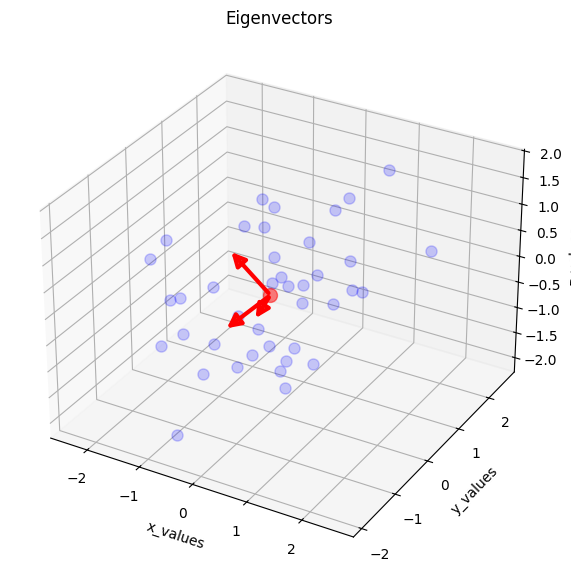

In [ ]:
%pylab inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch


class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        FancyArrowPatch.draw(self, renderer)

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        # This projects the 3D points to 2D and returns their depth.
        # We can use the mean depth for sorting.
        _, _, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        return np.mean(zs)

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([df['feature1'].mean()], [df['feature2'].mean()], [df['feature3'].mean()], 'o', markersize=10, color='red', alpha=0.5)
for v in eigen_vectors.T:
    a = Arrow3D([df['feature1'].mean(), df['feature1'].mean() + v[0]],
                [df['feature2'].mean(), df['feature2'].mean() + v[1]],
                [df['feature3'].mean(), df['feature3'].mean() + v[2]], mutation_scale=20,
                lw=3, arrowstyle="-|>", color="r")
    a.set_facecolor((0,0,0,0))
    ax.add_artist(a)
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')

plt.show()

In [ ]:
pc=eigen_vectors[0:2] #choosing the top 2 eigen vectors only

In [ ]:
pc

array([[-0.65807758, -0.68741145,  0.30724485],
       [-0.32175808, -0.11218211, -0.9401526 ]])

In [ ]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2  shape of new transformed matrix will be (40,2)
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,-0.428417,-0.126719,0
1,-1.710311,0.088635,0
2,1.260835,0.553989,1
3,0.363657,0.526229,0
4,-1.804331,-1.619550,0


#plotting in 2-D now

In [ ]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()

